In [40]:
from datasets import load_dataset
ds = load_dataset("SetFit/20_newsgroups")
print(ds)

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 11314
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7532
    })
})


In [41]:

# ── Cell 2: Inspect metadata & save splits to CSV ────────────────────────────
import os
import pandas as pd

# Print dataset structure from Cell 1 ds object
print(ds)
print(f"\nFeatures : {ds['train'].features}")
print(f"Splits   : {list(ds.keys())}")

SAVE_DIR = "20_newsgroups_data"
os.makedirs(SAVE_DIR, exist_ok=True)

for split, dataset in ds.items():
    df       = dataset.to_pandas()
    csv_path = os.path.join(SAVE_DIR, f"{split}.csv")
    df.to_csv(csv_path, index=False)
    print(f"[{split}] saved {len(df):,} rows  →  {csv_path}")

print(f"\nColumns : {df.columns.tolist()}")
print("\nSample rows :")
display(df.head(3))


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 11314
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7532
    })
})

Features : {'text': Value('string'), 'label': Value('int64'), 'label_text': Value('string')}
Splits   : ['train', 'test']
[train] saved 11,314 rows  →  20_newsgroups_data\train.csv
[test] saved 7,532 rows  →  20_newsgroups_data\test.csv

Columns : ['text', 'label', 'label_text']

Sample rows :


,text,label,label_text
0,I am a little confused on all of the models of...,7,rec.autos
1,I'm not familiar at all with the format of the...,5,comp.windows.x
2,"\nIn a word, yes.\n",0,alt.atheism


In [42]:

# ── Cell 3: Load from CSV + Text Preprocessing ───────────────────────────────
import re
import pandas as pd
import os
SAVE_DIR = "20_newsgroups_data"

train_df = pd.read_csv(os.path.join(SAVE_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(SAVE_DIR, "test.csv"))

print(f"Train : {len(train_df):,} rows  |  Test : {len(test_df):,} rows")
print(f"Columns : {train_df.columns.tolist()}")
print(f"\nClass distribution (train):\n{train_df['label'].value_counts().sort_index().to_string()}")


def preprocess_text(text: str) -> str:
    """
    Clean a 20-newsgroups post:
      1. Lowercase
      2. Strip common email-header lines  (From:, Subject:, etc.)
      3. Remove quoted reply lines         (lines starting with >)
      4. Remove URLs and e-mail addresses
      5. Keep only alphabetic characters
      6. Collapse whitespace
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Drop header lines
    text = re.sub(
        r"^(from|subject|organization|lines|nntp-posting-host|reply-to|x-newsreader)[^\n]*\n",
        "", text, flags=re.MULTILINE
    )
    # Drop quoted lines
    text = re.sub(r"^>.*\n?", "", text, flags=re.MULTILINE)
    # Remove URLs and e-mails
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+",          " ", text)
    # Letters only
    text = re.sub(r"[^a-z\s]", " ", text)
    # Collapse whitespace
    return re.sub(r"\s+", " ", text).strip()


train_df["clean_text"] = train_df["text"].apply(preprocess_text)
test_df["clean_text"]  = test_df["text"].apply(preprocess_text)

# Drop the rare totally-empty rows
train_df = train_df[train_df["clean_text"].str.len() > 0].reset_index(drop=True)
test_df  = test_df[test_df["clean_text"].str.len() > 0].reset_index(drop=True)

print(f"\nAfter cleaning — Train : {len(train_df):,}  |  Test : {len(test_df):,}")
print("\nSample cleaned text (first 300 chars) :")
print(train_df["clean_text"].iloc[0][:300])


Train : 11,314 rows  |  Test : 7,532 rows
Columns : ['text', 'label', 'label_text']

Class distribution (train):
label
0     480
1     584
2     591
3     590
4     578
5     593
6     585
7     594
8     598
9     597
10    600
11    595
12    591
13    594
14    593
15    599
16    546
17    564
18    465
19    377

After cleaning — Train : 11,000  |  Test : 7,303

Sample cleaned text (first 300 chars) :
i was wondering if anyone out there could enlighten me on this car i saw the other day it was a door sports car looked to be from the late s early s it was called a bricklin the doors were really small in addition the front bumper was separate from the rest of the body this is all i know if anyone c


In [43]:

# ── Cell 4: Build Vocabulary & Encode Sequences ──────────────────────────────
from collections import Counter
import numpy as np

# ── Sequence config ───────────────────────────────────────────────────────────
MAX_SEQ_LEN = 128   # total token budget per sample (includes [CLS])
MIN_FREQ    = 2     # discard tokens appearing fewer than MIN_FREQ times in train

# Special tokens — indices must be stable (PAD = 0 for padding_idx in Embedding)
PAD_TOKEN = "<PAD>"   # idx 0  ← padding, masked out everywhere
UNK_TOKEN = "<UNK>"   # idx 1  ← out-of-vocabulary words
CLS_TOKEN = "<CLS>"   # idx 2  ← prepended; its final hidden state → classifier

# ── Build vocab from TRAIN only (no test data leakage) ───────────────────────
print("Building vocabulary from training data …")
counter = Counter()
for text in train_df["clean_text"]:
    counter.update(text.split())

kept     = sorted(tok for tok, cnt in counter.items() if cnt >= MIN_FREQ)
vocab    = [PAD_TOKEN, UNK_TOKEN, CLS_TOKEN] + kept
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

VOCAB_SIZE  = len(vocab)
NUM_CLASSES = train_df["label"].nunique()
print(f"Vocabulary size   : {VOCAB_SIZE:,}  (kept words with freq ≥ {MIN_FREQ})")
print(f"Number of classes : {NUM_CLASSES}")

# ── Remap labels to strict 0 … NUM_CLASSES-1 (safe even if IDs have gaps) ────
unique_labels = sorted(train_df["label"].unique())
label_remap   = {old: new for new, old in enumerate(unique_labels)}
train_df["label"] = train_df["label"].map(label_remap)
test_df["label"]  = test_df["label"].map(label_remap)

# Human-readable class names (use label_text column if present)
if "label_text" in train_df.columns:
    LABEL_NAMES = (
        train_df.drop_duplicates("label")
                .sort_values("label")["label_text"]
                .tolist()
    )
else:
    LABEL_NAMES = [str(i) for i in range(NUM_CLASSES)]
print(f"\nClass names:\n{LABEL_NAMES}")


def encode(text: str, word2idx: dict, max_len: int) -> list:
    """
    Tokenise by whitespace, prepend [CLS], truncate to max_len,
    then right-pad to exactly max_len with <PAD>.

    Result: [CLS_idx, w1, w2, …, <PAD>, <PAD>, …]
            |← always exactly max_len tokens →|
    """
    tokens = text.split()[: max_len - 1]          # reserve 1 slot for [CLS]
    ids    = (
        [word2idx[CLS_TOKEN]]
        + [word2idx.get(t, word2idx[UNK_TOKEN]) for t in tokens]
    )
    ids = ids[:max_len]
    ids += [word2idx[PAD_TOKEN]] * (max_len - len(ids))
    return ids


# Apply encoding to both splits
train_df["input_ids"] = train_df["clean_text"].apply(
    lambda t: encode(t, word2idx, MAX_SEQ_LEN)
)
test_df["input_ids"] = test_df["clean_text"].apply(
    lambda t: encode(t, word2idx, MAX_SEQ_LEN)
)

# Quick verification
sample_ids   = train_df["input_ids"].iloc[0]
sample_words = [idx2word[i] for i in sample_ids[:15]]
print(f"\nSample input_ids  (first 15) : {sample_ids[:15]}")
print(f"Corresponding words          : {sample_words}")
print(f"Sequence length check        : {len(sample_ids)} (should be {MAX_SEQ_LEN})")


Building vocabulary from training data …
Vocabulary size   : 35,916  (kept words with freq ≥ 2)
Number of classes : 20

Class names:
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Sample input_ids  (first 15) : [2, 14691, 34151, 34736, 14813, 1389, 22334, 31435, 6687, 10076, 19179, 21984, 31503, 4456, 14691]
Corresponding words          : ['<CLS>', 'i', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'i']
Sequence length check        : 128 (should be 128)


In [44]:

# ── Cell 5: PyTorch Dataset & DataLoaders ────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader

BATCH_SIZE = 64
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


class NewsGroupDataset(Dataset):
    """Wraps a DataFrame into a PyTorch Dataset."""

    def __init__(self, df):
        self.input_ids = torch.tensor(df["input_ids"].tolist(), dtype=torch.long)
        self.labels    = torch.tensor(df["label"].tolist(),     dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.labels[idx]


train_dataset = NewsGroupDataset(train_df)
test_dataset  = NewsGroupDataset(test_df)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=(DEVICE.type == "cuda")
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE.type == "cuda")
)

print(f"Train : {len(train_dataset):,} samples  →  {len(train_loader)} batches")
print(f"Test  : {len(test_dataset):,} samples  →  {len(test_loader)} batches")

# Quick shape sanity-check
ids_batch, lbl_batch = next(iter(train_loader))
print(f"\nBatch input_ids shape : {ids_batch.shape}")   # (64, 128)
print(f"Batch labels    shape : {lbl_batch.shape}")     # (64,)


Using device: cpu
Train : 11,000 samples  →  172 batches
Test  : 7,303 samples  →  115 batches

Batch input_ids shape : torch.Size([64, 128])
Batch labels    shape : torch.Size([64])


In [45]:

# ── Cell 6: Full Transformer Architecture — From Scratch ─────────────────────
#
#  We implement every component exactly as described in:
#    "Attention Is All You Need" — Vaswani et al., 2017
#  with two modern tweaks:
#    · Pre-LayerNorm  (normalise before each sub-layer, more stable)
#    · GELU activation in FFN (instead of the original ReLU)
#
#  Data flow:
#    input_ids (B, L)
#      → Token Embedding  (B, L, D)
#      → + Positional Encoding
#      → N × Encoder Layer  [ Self-Attention + FFN ]
#      → Extract [CLS] at position 0  (B, D)
#      → Classification Head  → logits (B, num_classes)
# ─────────────────────────────────────────────────────────────────────────────

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


# ═════════════════════════════════════════════════════════════════════════════
# 1.  Sinusoidal Positional Encoding  (§3.5 in the paper)
# ═════════════════════════════════════════════════════════════════════════════
class PositionalEncoding(nn.Module):
    """
    Adds a *fixed* (non-learnable) positional signal to embeddings so the model
    knows which token comes first, second, etc.

    The encoding for position `pos` and dimension `i` is:
        PE(pos, 2i)   = sin(pos / 10000^{2i/d_model})
        PE(pos, 2i+1) = cos(pos / 10000^{2i/d_model})

    Using sin/cos at different frequencies means every position gets a unique
    fingerprint, and the model can generalise to longer sequences than it trained
    on (because of the smooth, periodic nature of sin/cos).
    """

    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the (max_len, d_model) positional table once
        pe       = torch.zeros(max_len, d_model)                     # (L, D)
        position = torch.arange(0, max_len).unsqueeze(1).float()     # (L, 1)
        # log-space computation of 10000^(2i/d_model) is numerically stable
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10_000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)   # even dimensions
        pe[:, 1::2] = torch.cos(position * div_term)   # odd  dimensions

        # register_buffer: saved in state_dict but NOT a trainable parameter
        self.register_buffer("pe", pe.unsqueeze(0))    # (1, L, D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (batch, seq_len, d_model)
        # self.pe[:, :seq_len] broadcasts over the batch dimension
        return self.dropout(x + self.pe[:, : x.size(1)])


# ═════════════════════════════════════════════════════════════════════════════
# 2.  Scaled Dot-Product Attention  (§3.2.1)
# ═════════════════════════════════════════════════════════════════════════════
def scaled_dot_product_attention(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor = None,
):
    """
    The core attention operation:

        Attention(Q, K, V) = softmax( Q·Kᵀ / √d_k ) · V

    Dividing by √d_k prevents the dot products from growing too large in
    magnitude, which would push softmax into saturation (near-zero gradients).

    Args:
        Q, K, V : (..., seq_len, d_k)   – can have any leading batch/head dims
        mask    : (..., seq_q, seq_k)   – 0 means "ignore this key position"

    Returns:
        context        : (..., seq_q, d_k)
        attn_weights   : (..., seq_q, seq_k)  — useful for visualisation
    """
    d_k    = Q.size(-1)
    # Raw alignment scores  (B, heads, seq_q, seq_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        # Padding positions receive a score of -inf so softmax gives them 0
        scores = scores.masked_fill(mask == 0, float("-1e9"))

    attn_weights = F.softmax(scores, dim=-1)          # (…, seq_q, seq_k)
    context      = torch.matmul(attn_weights, V)      # (…, seq_q, d_k)
    return context, attn_weights


# ═════════════════════════════════════════════════════════════════════════════
# 3.  Multi-Head Self-Attention  (§3.2.2)
# ═════════════════════════════════════════════════════════════════════════════
class MultiHeadAttention(nn.Module):
    """
    Instead of one big attention operation over d_model dimensions, we run
    h smaller attention operations in parallel ("heads"), each in a d_k = d_model/h
    dimensional subspace.  Different heads learn different relationship types
    (e.g. syntax vs. coreference vs. positional proximity).

        MultiHead(Q,K,V) = Concat(head_1, …, head_h) · W_O
              head_i     = Attention( Q·W_Qi, K·W_Ki, V·W_Vi )

    Implementation trick: instead of h separate weight matrices, we use one
    large projection and then reshape — same computation, far more efficient.
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, (
            f"d_model ({d_model}) must be divisible by num_heads ({num_heads})"
        )
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads   # per-head dimension

        # Four projection matrices (Q, K, V inputs; O output)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    # ── helper: split the last dim into (num_heads, d_k) then transpose ───────
    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, seq, d_model)  →  (B, heads, seq, d_k)"""
        B, S, _ = x.size()
        return (
            x.view(B, S, self.num_heads, self.d_k)
             .transpose(1, 2)           # swap seq and heads axes
        )

    def forward(
        self,
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        mask: torch.Tensor = None,
    ) -> torch.Tensor:
        B = Q.size(0)

        # 1. Linear project and split into h heads  → (B, heads, seq, d_k)
        Q = self._split_heads(self.W_Q(Q))
        K = self._split_heads(self.W_K(K))
        V = self._split_heads(self.W_V(V))

        # 2. Scaled dot-product attention in every head simultaneously
        context, _ = scaled_dot_product_attention(Q, K, V, mask)
        # context: (B, heads, seq, d_k)

        # 3. Concatenate heads  →  (B, seq, d_model)
        context = (
            context.transpose(1, 2)            # (B, seq, heads, d_k)
                   .contiguous()
                   .view(B, -1, self.num_heads * self.d_k)
        )

        # 4. Final linear projection + dropout
        return self.dropout(self.W_O(context))


# ═════════════════════════════════════════════════════════════════════════════
# 4.  Position-wise Feed-Forward Network  (§3.3)
# ═════════════════════════════════════════════════════════════════════════════
class FeedForwardNetwork(nn.Module):
    """
    Applied independently to each token position (hence "position-wise"):

        FFN(x) = GELU( x · W_1 + b_1 ) · W_2 + b_2

    The d_ff inner dimension is typically 4× d_model — it "expands" the
    representation into a richer space, lets the model compute more complex
    functions, then projects back down.

    We use GELU instead of the original ReLU; empirically it converges faster
    for NLP tasks because it has a smooth gradient everywhere.
    """

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff,    d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(self.dropout(F.gelu(self.linear1(x))))


# ═════════════════════════════════════════════════════════════════════════════
# 5.  Transformer Encoder Layer  (Pre-LayerNorm variant)
# ═════════════════════════════════════════════════════════════════════════════
class TransformerEncoderLayer(nn.Module):
    """
    One encoder "block" — stacked N times to form the full encoder.

    The original paper uses Post-LN:
        x = LayerNorm( x + SubLayer(x) )

    We use Pre-LN (layer-norm BEFORE each sub-layer), which is more stable:
        x = x + SubLayer( LayerNorm(x) )

    This is because gradients flow through the residual path unchanged,
    avoiding vanishing gradients in deep stacks.

    Sub-layers:
        1. Multi-Head Self-Attention  — tokens "look at" each other
        2. Feed-Forward Network       — per-position non-linear transform
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn       = FeedForwardNetwork(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        # ── Sub-layer 1: Multi-Head Self-Attention (with residual) ────────────
        #   Q = K = V = x  (self-attention: every token attends to every token)
        normed = self.norm1(x)
        x = x + self.dropout(self.self_attn(normed, normed, normed, mask))
        # ── Sub-layer 2: Feed-Forward (with residual) ─────────────────────────
        x = x + self.ffn(self.norm2(x))
        return x


# ═════════════════════════════════════════════════════════════════════════════
# 6.  Stacked Transformer Encoder  (N layers)
# ═════════════════════════════════════════════════════════════════════════════
class TransformerEncoder(nn.Module):
    """
    N identical encoder layers stacked sequentially.  Each layer refines
    the token representations from the previous one.  The final LayerNorm
    stabilises the output before it reaches the classification head.
    """

    def __init__(
        self, d_model: int, num_heads: int, num_layers: int,
        d_ff: int, dropout: float
    ):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)   # applied once after all N layers

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


# ═════════════════════════════════════════════════════════════════════════════
# 7.  Full Text Classifier  (glues everything together)
# ═════════════════════════════════════════════════════════════════════════════
class TransformerClassifier(nn.Module):
    """
    End-to-end architecture:

        input_ids  (B, seq_len)
            ↓
        Token Embedding   (vocab_size → d_model)
            ↓
        Positional Encoding   (adds sinusoidal position signal)
            ↓
        Transformer Encoder   (N × encoder layers with self-attention)
            ↓
        Extract [CLS] hidden state at position 0   → (B, d_model)
            ↓
        Classification Head   Linear → GELU → Dropout → Linear
            ↓
        logits   (B, num_classes)

    The [CLS] token (index 0) is prepended to every sequence.  After N
    layers of self-attention it aggregates information from all other tokens,
    making it a natural sequence-level representation — same idea as BERT.
    """

    def __init__(
        self,
        vocab_size:  int,
        num_classes: int,
        d_model:     int   = 128,
        num_heads:   int   = 4,
        num_layers:  int   = 3,
        d_ff:        int   = 512,
        max_len:     int   = 128,
        dropout:     float = 0.1,
        pad_idx:     int   = 0,
    ):
        super().__init__()
        # Token Embedding — padding positions are initialised to zero and
        # never receive a gradient (padding_idx=pad_idx)
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.encoder   = TransformerEncoder(
            d_model, num_heads, num_layers, d_ff, dropout
        )
        # Two-layer classification head with a bottleneck
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        """
        Xavier uniform init keeps the variance of activations roughly constant
        across layers at the start of training, preventing vanishing/exploding
        gradients in the first few steps.
        """
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_padding_mask(
        self, input_ids: torch.Tensor, pad_idx: int = 0
    ) -> torch.Tensor:
        """
        Build a boolean mask  (B, 1, 1, seq_len).
        Value = 1 means "attend to this position"
        Value = 0 means "this is a PAD token — ignore it in attention"
        The shape is broadcastable over (B, heads, seq_q, seq_k).
        """
        return (input_ids != pad_idx).unsqueeze(1).unsqueeze(2)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        # ── 1. Build padding mask ─────────────────────────────────────────────
        mask = self.make_padding_mask(input_ids).to(input_ids.device)

        # ── 2. Convert token IDs → dense vectors + add positional signal ──────
        x = self.embedding(input_ids)   # (B, seq, d_model)
        x = self.pos_enc(x)             # (B, seq, d_model) + sinusoidal PE

        # ── 3. Pass through N encoder layers ─────────────────────────────────
        x = self.encoder(x, mask)       # (B, seq, d_model)

        # ── 4. Use only the [CLS] token (position 0) for classification ───────
        cls_repr = x[:, 0, :]           # (B, d_model)

        # ── 5. Classification head → raw logits ───────────────────────────────
        return self.classifier(cls_repr)  # (B, num_classes)


# ─────────────────────────────────────────────────────────────────────────────
# Quick sanity check
# ─────────────────────────────────────────────────────────────────────────────
_tmp = TransformerClassifier(
    vocab_size=VOCAB_SIZE, num_classes=NUM_CLASSES,
    d_model=128, num_heads=4, num_layers=3, d_ff=512,
    max_len=MAX_SEQ_LEN, dropout=0.1, pad_idx=0
)
_x   = torch.zeros(2, MAX_SEQ_LEN, dtype=torch.long)
_out = _tmp(_x)
assert _out.shape == (2, NUM_CLASSES), f"Bad output shape: {_out.shape}"

total_params     = sum(p.numel() for p in _tmp.parameters())
trainable_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print("Sanity check passed ✓")
print(f"Input  : {list(_x.shape)}  →  Output : {list(_out.shape)}  "
      f"(expected [2, {NUM_CLASSES}])")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
del _tmp, _x, _out


Sanity check passed ✓
Input  : [2, 128]  →  Output : [2, 20]  (expected [2, 20])
Total parameters     : 5,200,724
Trainable parameters : 5,200,724


In [ ]:

# ── Cell 7: Training Setup ───────────────────────────────────────────────────
import math
import torch.optim as optim

# ── Hyperparameters ────────────────────────────────────────────────────────────
D_MODEL      = 256
NUM_HEADS    = 4
NUM_LAYERS   = 4
D_FF         = 512
DROPOUT      = 0
NUM_EPOCHS   = 20
LR           = 5e-4
WEIGHT_DECAY = 5e-4
WARMUP_RATIO = 0.05     # first 5% of steps used for linear LR warmup

# ── Build model ───────────────────────────────────────────────────────────────
model = TransformerClassifier(
    vocab_size  = VOCAB_SIZE,
    num_classes = NUM_CLASSES,
    d_model     = D_MODEL,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    d_ff        = D_FF,
    max_len     = MAX_SEQ_LEN,
    dropout     = DROPOUT,
    pad_idx     = 0,
).to(DEVICE)

# ── Loss — label smoothing discourages over-confident predictions ──────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ── Optimizer — AdamW decouples weight decay from adaptive moments ─────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── Scheduler — linear warmup followed by cosine annealing ────────────────────
# Warmup: ramp LR from 0 → LR over `warmup_steps`
# Annealing: smoothly decay LR from LR → ~0 over the remaining steps
total_steps  = NUM_EPOCHS * len(train_loader)
warmup_steps = int(total_steps * WARMUP_RATIO)


def lr_lambda(current_step: int) -> float:
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(
        max(1, total_steps - warmup_steps)
    )
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Device            : {DEVICE}")
print(f"Trainable params  : {sum(p.numel() for p in model.parameters()):,}")
print(f"Total steps       : {total_steps}  |  Warmup steps : {warmup_steps}")
print(f"Batch size        : {BATCH_SIZE}  |  Epochs : {NUM_EPOCHS}")


Device            : cpu
Trainable params  : 11,335,828
Total steps       : 3440  |  Warmup steps : 34
Batch size        : 64  |  Epochs : 20


In [47]:

# ── Cell 7b: Save vocab & model config for the Streamlit demo ────────────────
# Run this ONCE after Cell 4 (vocab) and Cell 7 (training setup).
# The demo app loads these two files instead of re-building from scratch.
import json

meta = {
    # Vocabulary (token → integer index)
    "word2idx"   : word2idx,
    "label_names": LABEL_NAMES,
    # Hyperparameters that define the model architecture
    "model_config": {
        "vocab_size" : VOCAB_SIZE,
        "num_classes": NUM_CLASSES,
        "d_model"    : D_MODEL,
        "num_heads"  : NUM_HEADS,
        "num_layers" : NUM_LAYERS,
        "d_ff"       : D_FF,
        "max_len"    : MAX_SEQ_LEN,
        "dropout"    : 0.0,   # 0 at inference — dropout disabled automatically by model.eval()
        "pad_idx"    : 0,
    },
}

with open("model_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False)

print("Saved → model_meta.json")
print(f"  vocab size   : {len(word2idx):,}")
print(f"  num classes  : {len(LABEL_NAMES)}")
print(f"  label names  : {LABEL_NAMES}")


Saved → model_meta.json
  vocab size   : 35,916
  num classes  : 20
  label names  : ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [ ]:

# ── Cell 8: Training & Evaluation Loops ──────────────────────────────────────
import time


def train_one_epoch(model, loader, optimizer, criterion, scheduler, device):
    """
    One full pass through the training data.
    Returns (average_loss, accuracy) over the epoch.
    """
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for input_ids, labels in loader:
        input_ids = input_ids.to(device)
        labels    = labels.to(device)

        optimizer.zero_grad()

        logits = model(input_ids)          # forward pass
        loss   = criterion(logits, labels) # compute loss

        loss.backward()                    # backprop

        # Clip gradients — prevents rare exploding-gradient spikes
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()   # update weights
        scheduler.step()   # update LR

        preds       = logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total_loss += loss.item() * labels.size(0)
        n          += labels.size(0)

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluation pass (no gradients).
    Returns (average_loss, accuracy).
    """
    model.eval()
    total_loss, correct, n = 0.0, 0, 0

    for input_ids, labels in loader:
        input_ids = input_ids.to(device)
        labels    = labels.to(device)

        logits = model(input_ids)
        loss   = criterion(logits, labels)

        preds       = logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total_loss += loss.item() * labels.size(0)
        n          += labels.size(0)

    return total_loss / n, correct / n


# ── Run training ──────────────────────────────────────────────────────────────
history   = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_acc  = 0.0
best_path = "best_transformer.pt"

header = (f"{'Epoch':>6} │ {'Train Loss':>10} │ {'Train Acc':>9} │ "
          f"{'Test Loss':>9} │ {'Test Acc':>8} │ {'LR':>8} │ Time")
print(header)
print("─" * len(header))

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scheduler, DEVICE
    )
    te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    current_lr = scheduler.get_last_lr()[0]
    elapsed    = time.time() - t0
    flag       = "  ← best" if te_acc > best_acc else ""

    print(f"{epoch:>6} │ {tr_loss:>10.4f} │ {tr_acc:>9.4f} │ "
          f"{te_loss:>9.4f} │ {te_acc:>8.4f} │ {current_lr:>8.2e} │ "
          f"{elapsed:.1f}s{flag}")

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save(model.state_dict(), best_path)

print(f"\nBest test accuracy : {best_acc:.4f}  ({best_acc * 100:.2f}%)")
print(f"Best checkpoint    : {best_path}")


 Epoch │ Train Loss │ Train Acc │ Test Loss │ Test Acc │       LR │ Time
────────────────────────────────────────────────────────────────────────
     1 │     3.0292 │    0.0492 │    2.9955 │   0.0516 │ 4.98e-02 │ 151.1s  ← best
     2 │     2.9982 │    0.0542 │    2.9989 │   0.0519 │ 4.90e-02 │ 159.1s  ← best
     3 │     2.9978 │    0.0485 │    2.9958 │   0.0508 │ 4.76e-02 │ 158.9s


Final test accuracy (best checkpoint) : 0.2025  (20.25%)


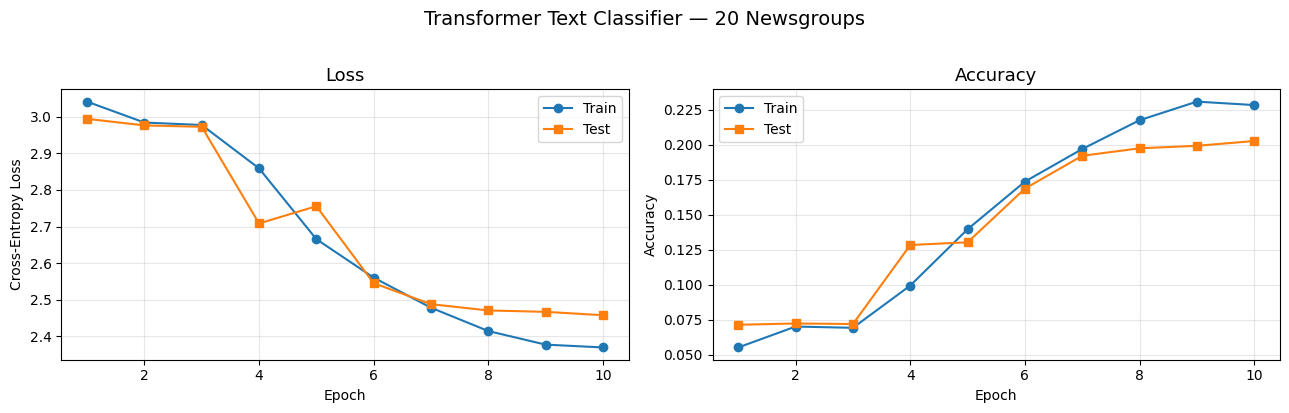

Saved → training_curves.png


In [ ]:

# ── Cell 9: Learning Curves & Final Evaluation ───────────────────────────────
import matplotlib.pyplot as plt

# Reload the best-performing checkpoint
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
_, final_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Final test accuracy (best checkpoint) : {final_acc:.4f}  ({final_acc * 100:.2f}%)")

# ── Plot ──────────────────────────────────────────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss
ax1.plot(epochs_range, history["train_loss"], "o-", label="Train")
ax1.plot(epochs_range, history["test_loss"],  "s-", label="Test")
ax1.set_title("Loss", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history["train_acc"], "o-", label="Train")
ax2.plot(epochs_range, history["test_acc"],  "s-", label="Test")
ax2.set_title("Accuracy", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle("Transformer Text Classifier — 20 Newsgroups", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_curves.png")


  Accuracy          : 0.2025  (20.25%)
  Macro Precision   : 0.1757
  Macro Recall      : 0.1966
  Macro F1          : 0.1694
  Weighted F1       : 0.1738

Per-class classification report:

                          precision    recall  f1-score   support

             alt.atheism     0.0465    0.0064    0.0113       311
           comp.graphics     0.1166    0.1667    0.1372       384
 comp.os.ms-windows.misc     0.2043    0.4011    0.2707       379
comp.sys.ibm.pc.hardware     0.1983    0.2390    0.2167       385
   comp.sys.mac.hardware     0.1639    0.1833    0.1730       371
          comp.windows.x     0.1548    0.0333    0.0549       390
            misc.forsale     0.5819    0.4555    0.5110       382
               rec.autos     0.0000    0.0000    0.0000       373
         rec.motorcycles     0.1131    0.0492    0.0686       386
      rec.sport.baseball     0.1408    0.3307    0.1975       381
        rec.sport.hockey     0.0000    0.0000    0.0000       390
               sc

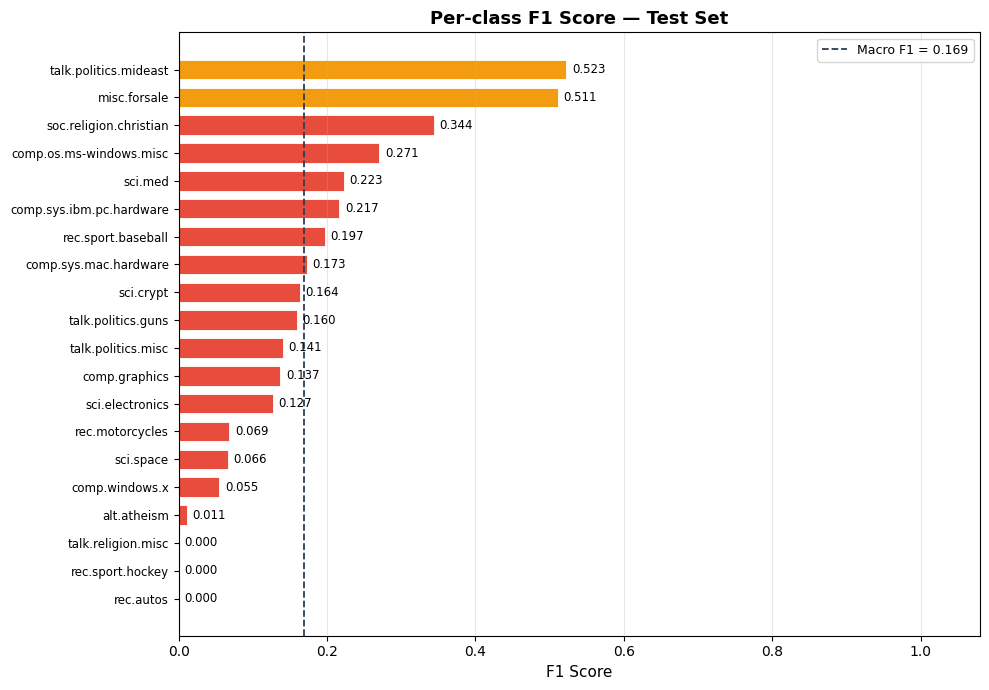

Saved → per_class_f1.png


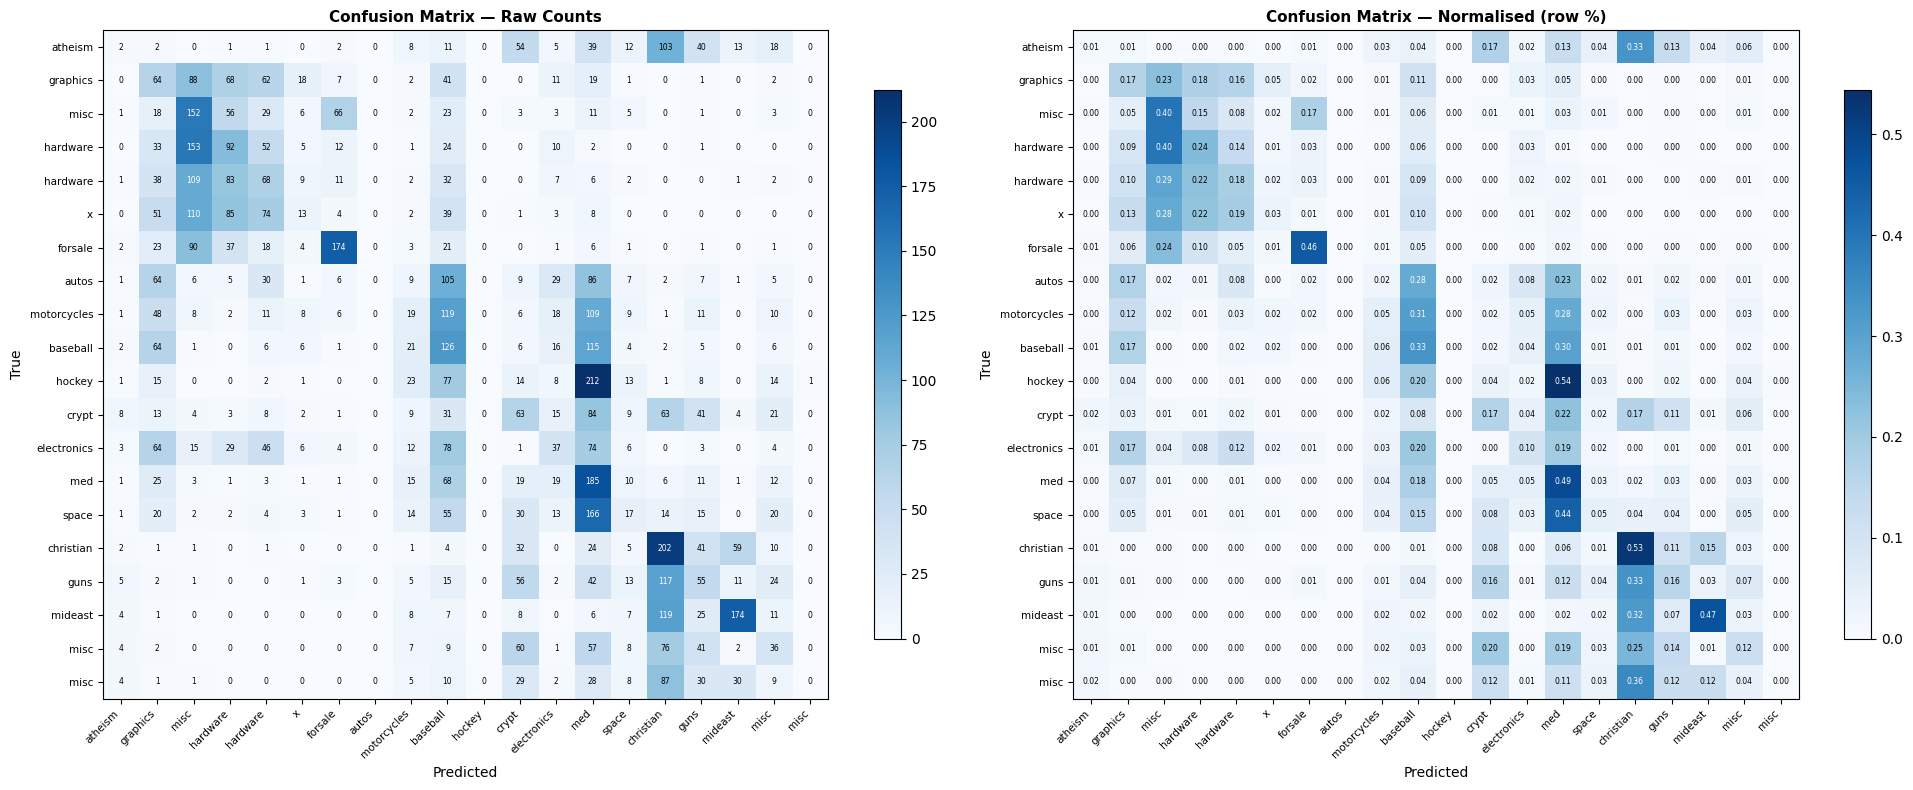

Saved → confusion_matrix.png


In [ ]:

# ── Cell 10: Detailed Evaluation Metrics ─────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

# ── Collect all predictions + probabilities on the test set ───────────────────
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []   # softmax probabilities for ROC

with torch.no_grad():
    for input_ids, labels in test_loader:
        logits = model(input_ids.to(DEVICE))
        probs  = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())
        all_probs.append(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.vstack(all_probs)   # (N, num_classes)

# ── 1. Scalar summary metrics ─────────────────────────────────────────────────
acc      = (all_preds == all_labels).mean()
macro_p  = precision_score(all_labels, all_preds, average="macro",    zero_division=0)
macro_r  = recall_score   (all_labels, all_preds, average="macro",    zero_division=0)
macro_f1 = f1_score       (all_labels, all_preds, average="macro",    zero_division=0)
wtd_f1   = f1_score       (all_labels, all_preds, average="weighted", zero_division=0)

print("=" * 54)
print(f"  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Macro Precision   : {macro_p:.4f}")
print(f"  Macro Recall      : {macro_r:.4f}")
print(f"  Macro F1          : {macro_f1:.4f}")
print(f"  Weighted F1       : {wtd_f1:.4f}")
print("=" * 54)

# ── 2. Full per-class classification report ───────────────────────────────────
print("\nPer-class classification report:\n")
print(
    classification_report(
        all_labels, all_preds,
        target_names=LABEL_NAMES,
        digits=4,
        zero_division=0,
    )
)

# ── 3. Per-class F1 bar chart ─────────────────────────────────────────────────
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
sort_idx     = np.argsort(per_class_f1)          # sort by F1 ascending
sorted_names = [LABEL_NAMES[i] for i in sort_idx]
sorted_f1    = per_class_f1[sort_idx]

# colour-code bars: green if F1 >= 0.7, orange if >= 0.5, red otherwise
bar_colors = ["#e74c3c" if v < 0.5 else "#f39c12" if v < 0.7 else "#2ecc71"
              for v in sorted_f1]

fig1, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(sorted_names, sorted_f1, color=bar_colors, edgecolor="white",
               linewidth=0.6, height=0.7)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8.5)
ax.set_xlim(0, 1.08)
ax.axvline(macro_f1, color="#2c3e50", linestyle="--", linewidth=1.3,
           label=f"Macro F1 = {macro_f1:.3f}")
ax.set_xlabel("F1 Score", fontsize=11)
ax.set_title("Per-class F1 Score — Test Set", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.tick_params(axis="y", labelsize=8.5)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → per_class_f1.png")

# ── 4. Confusion matrix ───────────────────────────────────────────────────────
cm         = confusion_matrix(all_labels, all_preds)
cm_norm    = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

# Short labels (drop the first segment from e.g. "comp.graphics" → "graphics")
short_names = [n.split(".")[-1] if "." in n else n for n in LABEL_NAMES]

fig2, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax_cm, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix — Raw Counts", "Confusion Matrix — Normalised (row %)"],
    ["d", ".2f"],
):
    im = ax_cm.imshow(data, cmap="Blues", aspect="auto")
    plt.colorbar(im, ax=ax_cm, shrink=0.82)
    ax_cm.set_xticks(range(NUM_CLASSES))
    ax_cm.set_yticks(range(NUM_CLASSES))
    ax_cm.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7.5)
    ax_cm.set_yticklabels(short_names, fontsize=7.5)
    ax_cm.set_xlabel("Predicted", fontsize=10)
    ax_cm.set_ylabel("True",      fontsize=10)
    ax_cm.set_title(title,        fontsize=11, fontweight="bold")
    thresh = data.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = data[i, j]
            txt = (f"{val:.2f}" if fmt == ".2f" else str(int(val)))
            ax_cm.text(j, i, txt,
                       ha="center", va="center",
                       fontsize=5.5,
                       color="white" if val > thresh else "black")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrix.png")

# ── 5. AUC-ROC Curve (One-vs-Rest, macro-average) ────────────────────────────
# Binarize labels into a (N, num_classes) indicator matrix
classes        = list(range(NUM_CLASSES))
labels_bin     = label_binarize(all_labels, classes=classes)  # (N, C)

fpr_per_class  = {}
tpr_per_class  = {}
roc_auc        = {}

for i in range(NUM_CLASSES):
    fpr_per_class[i], tpr_per_class[i], _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr_per_class[i], tpr_per_class[i])

# Macro-average: interpolate all curves onto common FPR grid then average
all_fpr      = np.unique(np.concatenate([fpr_per_class[i] for i in classes]))
mean_tpr     = np.zeros_like(all_fpr)
for i in classes:
    mean_tpr += np.interp(all_fpr, fpr_per_class[i], tpr_per_class[i])
mean_tpr    /= NUM_CLASSES
macro_auc    = auc(all_fpr, mean_tpr)

# ── Plot: individual class curves (small multiples) ───────────────────────────
ncols = 5
nrows = math.ceil(NUM_CLASSES / ncols)
fig3, axes3 = plt.subplots(nrows, ncols, figsize=(ncols * 3.8, nrows * 3.2))
axes3_flat  = axes3.flatten()

for i in range(NUM_CLASSES):
    ax_r = axes3_flat[i]
    ax_r.plot(fpr_per_class[i], tpr_per_class[i],
              color="#3498db", lw=1.8, label=f"AUC = {roc_auc[i]:.3f}")
    ax_r.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    ax_r.set_xlim([0.0, 1.0])
    ax_r.set_ylim([0.0, 1.05])
    ax_r.set_title(short_names[i], fontsize=9, fontweight="bold")
    ax_r.legend(loc="lower right", fontsize=8)
    ax_r.set_xlabel("FPR", fontsize=8)
    ax_r.set_ylabel("TPR", fontsize=8)
    ax_r.tick_params(labelsize=7)
    ax_r.grid(True, alpha=0.25)

# Hide unused subplots
for j in range(NUM_CLASSES, len(axes3_flat)):
    axes3_flat[j].set_visible(False)

fig3.suptitle("Per-class ROC Curves (One-vs-Rest)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("roc_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → roc_per_class.png")

# ── Plot: macro-average ROC curve ─────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(7, 6))

# Draw individual class curves (faint)
cmap = plt.cm.get_cmap("tab20", NUM_CLASSES)
for i in range(NUM_CLASSES):
    ax4.plot(fpr_per_class[i], tpr_per_class[i],
             color=cmap(i), lw=0.9, alpha=0.4, label=f"{short_names[i]} ({roc_auc[i]:.2f})")

# Draw macro-average curve (bold)
ax4.plot(all_fpr, mean_tpr,
         color="#2c3e50", lw=2.8, linestyle="-",
         label=f"Macro-avg AUC = {macro_auc:.4f}")
ax4.plot([0, 1], [0, 1], "r--", lw=1.2, label="Random classifier")

ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel("False Positive Rate", fontsize=12)
ax4.set_ylabel("True Positive Rate",  fontsize=12)
ax4.set_title("ROC Curve — 20 Newsgroups (One-vs-Rest)", fontsize=13, fontweight="bold")
ax4.legend(loc="lower right", fontsize=7, ncol=2)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_macro.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → roc_macro.png")

# ── Print AUC summary ─────────────────────────────────────────────────────────
print(f"\n{'Class':<35} {'AUC':>6}")
print("─" * 43)
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name:<33} {roc_auc[i]:.4f}")
print("─" * 43)
print(f"  {'Macro-Average AUC':<33} {macro_auc:.4f}")


In [ ]:

# ── Cell 10: Inference — classify arbitrary text ──────────────────────────────
import torch.nn.functional as F   # already imported above, safe to re-import


def predict(text: str, model, word2idx: dict, max_len: int, device, label_names: list):
    """
    Preprocess → encode → forward → softmax.
    Returns (predicted_label, confidence, full probability tensor).
    """
    model.eval()
    clean = preprocess_text(text)
    ids   = encode(clean, word2idx, max_len)
    x     = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.no_grad():
        logits = model(x)

    probs      = F.softmax(logits, dim=-1).squeeze(0).cpu()
    class_idx  = probs.argmax().item()
    confidence = probs[class_idx].item()
    return label_names[class_idx], confidence, probs


# ── Try a few examples ────────────────────────────────────────────────────────
examples = [
    "NASA announces a new space telescope mission to study exoplanets.",
    "The new graphics card delivers outstanding performance in first-person shooters.",
    "The government proposed a new health-care bill affecting millions of citizens.",
    "The bishop held a sermon on forgiveness and redemption at the cathedral.",
    "The hockey team scored three goals in the final period to win the championship.",
    "Buy cheap medication online — discount prices and fast shipping guaranteed!",
]

print(f"{'Text (first 62 chars)':<64} {'Predicted Class':<35} {'Conf':>6}")
print("─" * 110)
for text in examples:
    label, conf, _ = predict(
        text, model, word2idx, MAX_SEQ_LEN, DEVICE, LABEL_NAMES
    )
    print(f"{text[:62]:<64} {label:<35} {conf:>6.4f}")


Text (first 62 chars)                                            Predicted Class                       Conf
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
NASA announces a new space telescope mission to study exoplane   rec.motorcycles                     0.1247
The new graphics card delivers outstanding performance in firs   misc.forsale                        0.3100
The government proposed a new health-care bill affecting milli   talk.politics.guns                  0.1267
The bishop held a sermon on forgiveness and redemption at the    rec.motorcycles                     0.1232
The hockey team scored three goals in the final period to win    rec.sport.baseball                  0.1974
Buy cheap medication online — discount prices and fast shippin   comp.os.ms-windows.misc             0.2770
